In [1]:
from google.colab import userdata
GIT_TOKEN=userdata.get('GITHUB_TOKEN')

In [2]:
# Install the Vela compiler toolchain
!pip install ethos-u-vela

In [3]:
# Secure clone and pip install your custom codebase using GitHub Token credentials
import os
GIT_USERNAME = "bencejdanko"
GIT_REPO = f"github.com/{GIT_USERNAME}/fomo-people-counting.git"

!git clone https://{GIT_USERNAME}:{GIT_TOKEN}@{GIT_REPO}
%cd /content/fomo-people-counting
!git pull
!pip install -e .

fatal: destination path 'fomo-people-counting' already exists and is not an empty directory.
/content/fomo-people-counting
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 483 bytes | 483.00 KiB/s, done.
From https://github.com/bencejdanko/fomo-people-counting
   e219275..510eff3  main       -> origin/main
Updating e219275..510eff3
Fast-forward
 fomo_core/model.py | 22 +++++++++++++++++++---
 1 file changed, 19 insertions(+), 3 deletions(-)
Obtaining file:///content/fomo-people-counting
  Preparing metadata (setup.py) ... done
  Attempting uninstall: fomo_core
    Found existing installation: fomo_core 1.0.0
    Uninstalling fomo_core-1.0.0:
      Successfully uninstalled fomo_core-1.0.0
  Running setup.py develop for fomo_core


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from fomo_core.annotation import RadialBoxCentroidAnnotator
from fomo_core.pipeline import (
    FomoDatasetBuilder,
    build_sample_arrays_from_hf_datasets,
    build_tf_dataset_from_hf_datasets,
)
from fomo_core.model import build_and_compile_fomo
from fomo_core.quantization import convert_to_int8_tflite
from fomo_core.postprocessing import extract_fomo_peaks, peaks_to_image_points

In [5]:
# 1. Pipeline Setup
repo_ids = [
    "bdanko/overhead-people-rgb",
    "bdanko/loaf_resolution_512",
]
# Merge preserved source labels such as Man, Woman, Person, ero, and 0 into one person class.
# The LOAF 180 FOV dataset contributes radial-aligned boxes, so prefer ritbox centers when present.
annotator = RadialBoxCentroidAnnotator(category_id=0, category_name="person", merge_all_categories=True)
builder = FomoDatasetBuilder(annotator=annotator)

# Load each dataset locally, then make deterministic 90/10 train/validation splits.
train_datasets = []
val_datasets = []
for repo_id in repo_ids:
    raw_dataset = load_dataset(repo_id, split="train")
    split_dataset = raw_dataset.train_test_split(test_size=0.10, seed=15179996, shuffle=True)
    train_datasets.append((repo_id, split_dataset["train"]))
    val_datasets.append((repo_id, split_dataset["test"]))
    print(f"{repo_id}: train={len(split_dataset['train'])}, val={len(split_dataset['test'])}")

print(
    f"Rows: train={sum(len(dataset) for _, dataset in train_datasets)}, "
    f"val={sum(len(dataset) for _, dataset in val_datasets)}"
)


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Rows: train=7702, val=856


In [6]:
# 2. Small In-Memory Samples
# Keep only a small preview/calibration subset in RAM; full training streams from HF rows.
preview_count = 150
X_train_preview, y_train_preview = build_sample_arrays_from_hf_datasets(
    builder,
    [dataset for _, dataset in train_datasets],
    sample_count=preview_count,
)
X_val_preview, y_val_preview = build_sample_arrays_from_hf_datasets(
    builder,
    [dataset for _, dataset in val_datasets],
    sample_count=preview_count,
)

print("Training preview tensors:", X_train_preview.shape, y_train_preview.shape)
print("Validation preview tensors:", X_val_preview.shape, y_val_preview.shape)


Extracting train features...
Extracting validation features...
Training tensors: (7702, 192, 192, 3) (7702, 24, 24, 2)
Validation tensors: (856, 192, 192, 3) (856, 24, 24, 2)


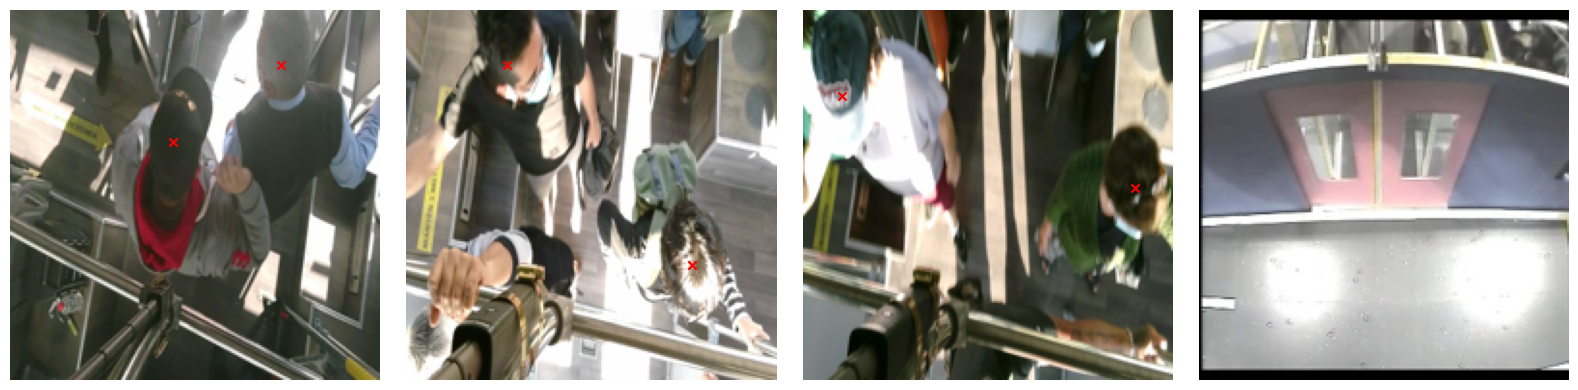

In [7]:
# 3. Sanity Visualization
def show_target_overlay(images, targets, count=4):
    count = min(count, len(images))
    fig, axes = plt.subplots(1, count, figsize=(4 * count, 4))
    if count == 1:
        axes = [axes]

    for ax, image, target in zip(axes, images[:count], targets[:count]):
        display_img = ((image + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
        ax.imshow(display_img)
        object_cells = np.argwhere(np.argmax(target, axis=-1) == 1)
        for grid_y, grid_x in object_cells:
            x = (grid_x + 0.5) * builder.input_size / builder.grid_size
            y = (grid_y + 0.5) * builder.input_size / builder.grid_size
            ax.scatter(x, y, c="red", s=35, marker="x")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

show_target_overlay(X_train_preview, y_train_preview)

In [8]:
# 4. TF Data Handlers
batch_size = 32
shuffle_buffer = 512
train_example_count = sum(len(dataset) for _, dataset in train_datasets)
val_example_count = sum(len(dataset) for _, dataset in val_datasets)
steps_per_epoch = int(np.ceil(train_example_count / batch_size))
validation_steps = int(np.ceil(val_example_count / batch_size))

train_ds = build_tf_dataset_from_hf_datasets(
    builder,
    [dataset for _, dataset in train_datasets],
)
train_ds = (
    train_ds
    .shuffle(min(train_example_count, shuffle_buffer), reshuffle_each_iteration=True)
    .map(builder.synchronized_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = build_tf_dataset_from_hf_datasets(
    builder,
    [dataset for _, dataset in val_datasets],
)
val_ds = (
    val_ds
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Training examples: {train_example_count} ({steps_per_epoch} steps/epoch)")
print(f"Validation examples: {val_example_count} ({validation_steps} validation steps)")


In [13]:
input_size = 192
grid_size = 24
alpha = 0.75
backbone_layer = "block_6_expand_relu"

builder = FomoDatasetBuilder(
    annotator=annotator,
    input_size=input_size,
    grid_size=grid_size,
)

model = build_and_compile_fomo(
    input_shape=(input_size, input_size, 3),
    alpha=alpha,
    backbone_layer=backbone_layer,
    lr=3e-4,
    background_weight=1.0,
    object_weight=90.0,
)

In [14]:
model.summary()

Model: "FOMO_Production"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 96, 96,    │        432 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 96, 96,    │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 96, 96,    │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 96, 96,    │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 96, 96,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 96, 96,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 96, 96, 8) │        128 │ expanded_conv_de… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 96, 96, 8) │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 96, 96,    │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 96, 96,    │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 96, 96,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 97, 97,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 48, 48,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 48, 48,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 48, 48,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 48, 48,    │        768 │ block_1_depthwis

 Total params: 24,082 (94.07 KB)

 Trainable params: 21,922 (85.63 KB)

 Non-trainable params: 2,160 (8.44 KB)

In [15]:
# 5. Engine Run
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
)

Epoch 1/40
241/241 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - loss: 0.7149 - object_precision: 0.0265 - object_recall: 0.7286 - val_loss: 0.4677 - val_object_precision: 0.0485 - val_object_recall: 0.5375 - learning_rate: 3.0000e-04
Epoch 2/40
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.3300 - object_precision: 0.0506 - object_recall: 0.7557 - val_loss: 0.4609 - val_object_precision: 0.0949 - val_object_recall: 0.4219 - learning_rate: 3.0000e-04
Epoch 3/40
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.2921 - object_precision: 0.0568 - object_recall: 0.7947 - val_loss: 0.4976 - val_object_precision: 0.1335 - val_object_recall: 0.3528 - learning_rate: 3.0000e-04
Epoch 4/40
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.2730 - object_precision: 0.0597 - object_recall: 0.8153 - val_loss: 0.5102 - val_object_precision: 0.1519 - val_object_recall: 0.3680 - learning_rate: 3.0000e-04
Epoch 5/40
238/241 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2663 - object_precision: 0.0612 - ob

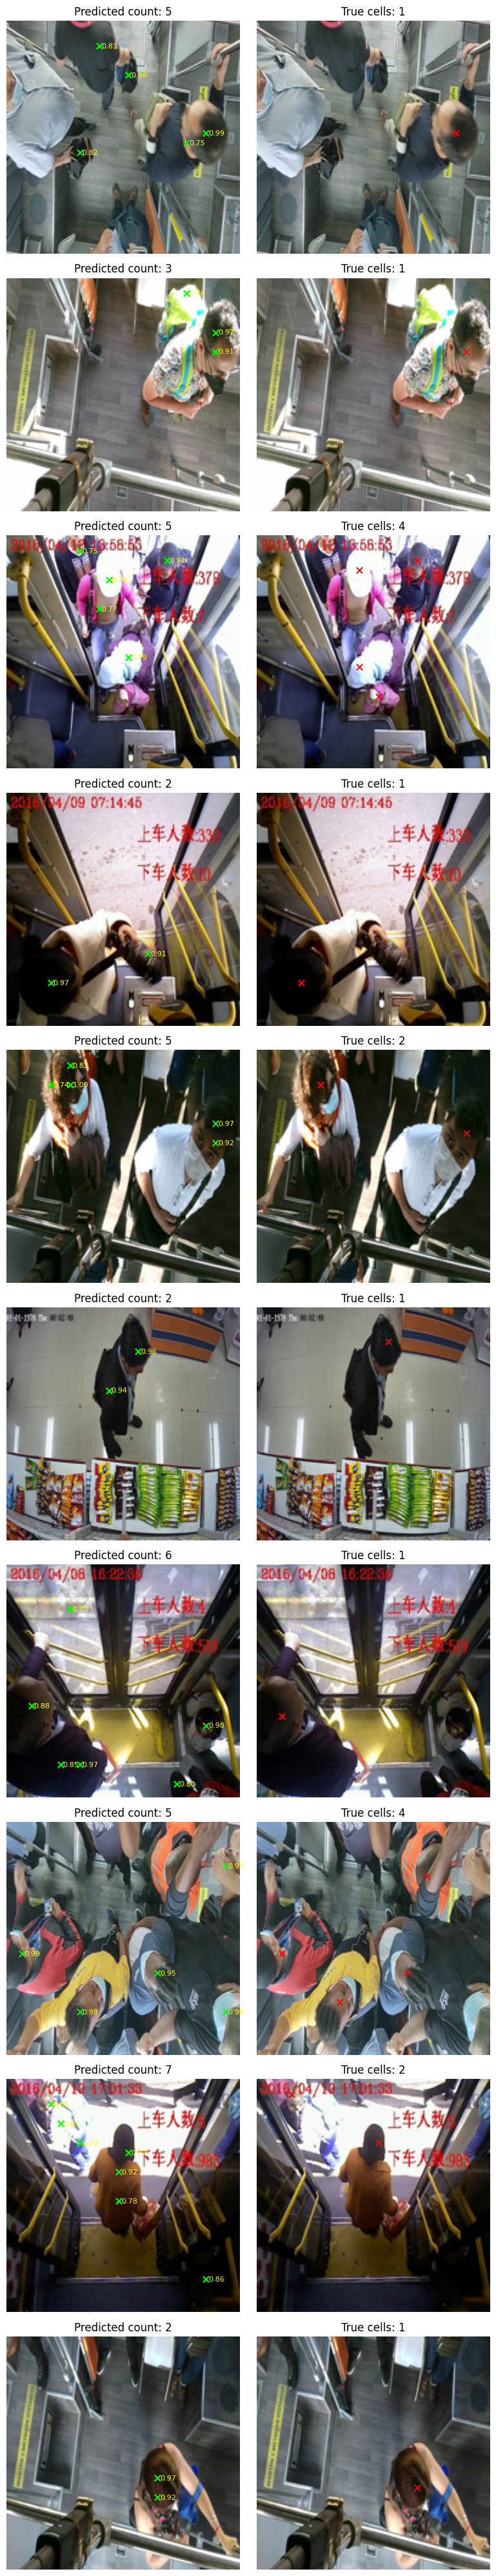

In [16]:
def show_fomo_peak_predictions(model, images, targets=None, count=6, threshold=0.7, min_distance=2):
    count = min(count, len(images))
    preds = model.predict(images[:count], verbose=0)

    cols = 2 if targets is not None else 1
    fig, axes = plt.subplots(count, cols, figsize=(4 * cols, 4 * count))
    if count == 1:
        axes = np.array([axes])
    if cols == 1:
        axes = np.array([[ax] for ax in axes])

    for i in range(count):
        display_img = ((images[i] + 1.0) * 127.5).clip(0, 255).astype(np.uint8)

        peaks = extract_fomo_peaks(
            preds[i],
            threshold=threshold,
            min_distance=min_distance,
        )
        points = peaks_to_image_points(
            peaks,
            input_size=builder.input_size,
            grid_size=builder.grid_size,
        )

        ax = axes[i, 0]
        ax.imshow(display_img)
        ax.set_title(f"Predicted count: {len(points)}")
        for point in points:
            ax.scatter(point["x"], point["y"], c="lime", s=45, marker="x")
            ax.text(point["x"] + 2, point["y"] + 2, f'{point["score"]:.2f}', color="yellow", fontsize=8)
        ax.set_axis_off()

        if targets is not None:
            true_cells = np.argwhere(np.argmax(targets[i], axis=-1) == 1)
            ax = axes[i, 1]
            ax.imshow(display_img)
            ax.set_title(f"True cells: {len(true_cells)}")
            for grid_y, grid_x in true_cells:
                x = (grid_x + 0.5) * builder.input_size / builder.grid_size
                y = (grid_y + 0.5) * builder.input_size / builder.grid_size
                ax.scatter(x, y, c="red", s=45, marker="x")
            ax.set_axis_off()

    plt.tight_layout()
    plt.show()

show_fomo_peak_predictions(model, X_val_preview, y_val_preview, count=10, threshold=0.7, min_distance=2)

In [17]:
# 6. INT8 Calibration
convert_to_int8_tflite(model, X_train_preview)

Saved artifact at '/tmp/tmp7wxgff0b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 192, 192, 3), dtype=tf.float32, name='image_input')
Output Type:
  TensorSpec(shape=(None, 24, 24, 2), dtype=tf.float32, name=None)
Captures:
  136000611659280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611660432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611660048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611660240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611658512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611659664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611659856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611659088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136000611661392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1360006

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized architecture exported successfully to fomo_production_int8.tflite


In [19]:
 # 7. Call the Vela compiler toolchain via bash
 # try swapping between Size/Performance
 # difference in optimization target can be ~50% difference
!vela fomo_production_int8.tflite \
  --accelerator-config ethos-u55-256 \
  --config /content/fomo-people-counting/configs/default_vela.ini \
  --memory-mode Shared_Sram \
  --system-config Ethos_U55_High_End_Embedded \
  --output-dir vela_output \
  --optimise Performance


Tensor 'serving_default_image_input:0' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'FOMO_Production_1/Conv1_relu_1/Relu6;FOMO_Production_1/bn_Conv1_1/batchnorm/add_1;FOMO_Production_1/Conv1_1/convolution;FOMO_Production_1/bn_Conv1_1/batchnorm/sub1' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'FOMO_Production_1/expanded_conv_depthwise_relu_1/Relu6;FOMO_Production_1/expanded_conv_depthwise_BN_1/batchnorm/add_1;FOMO_Production_1/expanded_conv_depthwise_BN_1/batchnorm/mul_1;FOMO_Production_1/expanded_conv_depthwise_1/depthwise;FOMO_Production_1/expanded_conv_depthwise_BN_1/batchnorm/mul;FOMO_Production_1/expanded_conv_depthwise_BN_1/batchnorm/sub' has a dynamic signature in axis 0. Setting shape axis 0 to 1 and proceeding.
Tensor 'FOMO_Production_1/expanded_conv_project_BN_1/batchnorm/add_1;FOMO_Production_1/expanded_conv_project_1/convolution;FOMO_Production_1/expanded_conv_project_BN_1/batchnorm/sub' has a dy